In [1]:
!pip install transformers

In [2]:
!pip install accelerate -U

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import os
import zipfile


file_path = '/content/drive/MyDrive/TransformesCod/02/Customer_Feedback_An/ProductsReviews[1].zip'
folder_path = '/content/drive/MyDrive/TransformesCod/02/Customer_Feedback_An'
save_output = folder_path + 'roberta_base_fine_tuned'

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(folder_path)

csv_file_path = os.path.join(folder_path, 'ProductsReviews.csv')

df = pd.read_csv(csv_file_path)
df.head()

,name,brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Purchased on Black FridayPros - Great Price (e...,Powerful tablet,Positive
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two do...,Amazon Echo Plus AWESOME,Positive
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few ...,Average,Neutral
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and ...",Greattttttt,Positive
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bough...,Very durable!,Positive


In [5]:
df = df[['reviews.text' , 'sentiment']]
df

,reviews.text,sentiment
0,Purchased on Black FridayPros - Great Price (e...,Positive
1,I purchased two Amazon in Echo Plus and two do...,Positive
2,Just an average Alexa option. Does show a few ...,Neutral
3,"very good product. Exactly what I wanted, and ...",Positive
4,This is the 3rd one I've purchased. I've bough...,Positive
...,...,...
3995,"It‚Äôs fun for the family to play with, but it...",Positive
3996,"I love the Kindle, it is a great product. It r...",Positive
3997,I was looking for a blutooth speaker to use wi...,Positive
3998,This is the second Amazon Fire 7 tablet I have...,Positive


In [6]:
counts = df['sentiment'].value_counts()
counts

,count
sentiment,
Positive,3749
Neutral,158
Negative,93


<Axes: title={'center': 'Reviews'}, xlabel='Rating', ylabel='Count'>

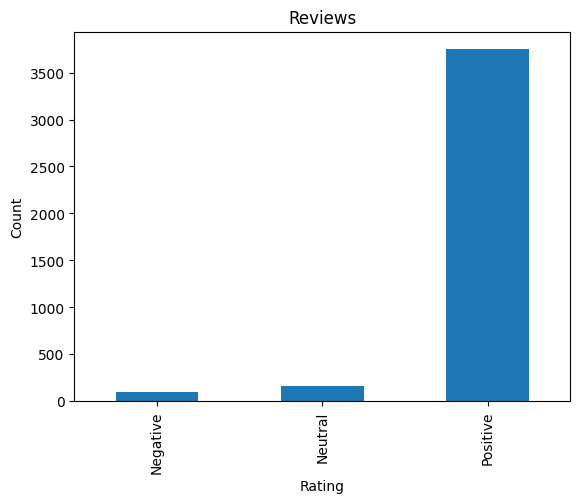

In [7]:
plt = counts.sort_index().plot(kind='bar' , title='Reviews')
plt.set_xlabel('Rating')
plt.set_ylabel('Count')
plt

<Axes: title={'center': 'Reviews'}, ylabel='count'>

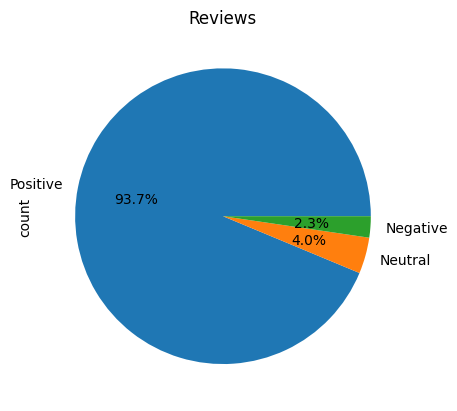

In [8]:
plt1 = counts.plot(kind='pie' , autopct='%1.1f%%' , title='Reviews')
plt1

In [9]:
def map_sentiment(sentiment):
  if sentiment == 'Positive':
    return 2
  elif sentiment == 'Negative':
    return 0
  elif sentiment == 'Neutral':
    return 1

df['Class'] = df['sentiment'].apply(map_sentiment)
df.head()

,reviews.text,sentiment,Class
0,Purchased on Black FridayPros - Great Price (e...,Positive,2
1,I purchased two Amazon in Echo Plus and two do...,Positive,2
2,Just an average Alexa option. Does show a few ...,Neutral,1
3,"very good product. Exactly what I wanted, and ...",Positive,2
4,This is the 3rd one I've purchased. I've bough...,Positive,2


In [10]:
from numpy.random.mtrand import rand
total_rows = 300
class_rows = int(total_rows /3)

df_class_0 = df[df['Class'] == 0]
df_class_1 = df[df['Class'] == 1]
df_class_2 = df[df['Class'] == 2]

simple_class_0 = df_class_0.sample(n=min(class_rows , len(df_class_0)),random_state=42)
simple_class_1 = df_class_1.sample(n=min(class_rows , len(df_class_1)),random_state=42)
simple_class_2 = df_class_2.sample(n=min(class_rows , len(df_class_2)),random_state=42)

df_final = pd.concat([simple_class_0 , simple_class_1 , simple_class_2])

In [11]:
counts = df_final['Class'].value_counts()
counts

,count
Class,
1,100
2,100
0,93


<Axes: title={'center': 'Reviews'}, ylabel='count'>

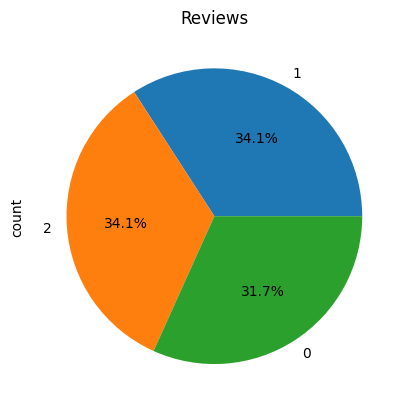

In [12]:
plt1 = counts.plot(kind='pie' , autopct='%1.1f%%' , title='Reviews')
plt1

In [13]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaForSequenceClassification.from_pretrained('roberta-base' , num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
from transformers import TrainingArguments , Trainer
from sklearn.metrics import accuracy_score

text = df_final['reviews.text'].tolist()
labels = df_final['Class'].tolist()


from sklearn.model_selection import train_test_split

text_train , text_test , labels_train , labels_test = train_test_split(text , labels , test_size=0.2 , stratify=labels)

tokenized_texts_train = tokenizer(text_train , padding=True , truncation=True , return_tensors='pt')
tokenized_texts_test = tokenizer(text_test , padding=True , truncation=True , return_tensors='pt')

labels_train = torch.tensor(labels_train)
labels_test = torch.tensor(labels_test)

train_dataset = []
for i in range(len(tokenized_texts_train['input_ids'])):
  input_ids = tokenized_texts_train['input_ids'][i]
  attention_mask = tokenized_texts_train['attention_mask'][i]
  label = labels_train[i].item()
  train_dataset.append({'input_ids' : input_ids , 'attention_mask' : attention_mask , 'label' : label})


test_dataset = []
for i in range(len(tokenized_texts_test['input_ids'])):
  input_ids = tokenized_texts_test['input_ids'][i]
  attention_mask = tokenized_texts_test['attention_mask'][i]
  label = labels_test[i].item()
  test_dataset.append({'input_ids' : input_ids , 'attention_mask' : attention_mask , 'label' : label})


training_args = TrainingArguments(
    output_dir=save_output,
    num_train_epochs=8,
    per_device_train_batch_size=2,
    save_strategy='epoch',
    report_to='none'
)


def cumpute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  accuracy = accuracy_score(labels , preds)
  return {'accuracy' : accuracy}


trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    processing_class = tokenizer,
    compute_metrics = cumpute_metrics
)

trainer.train()


Step,Training Loss
500,1.060533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=936, training_loss=0.9724484631138989, metrics={'train_runtime': 216.5851, 'train_samples_per_second': 8.643, 'train_steps_per_second': 4.322, 'total_flos': 213565872252096.0, 'train_loss': 0.9724484631138989, 'epoch': 8.0})

In [24]:

train_results = trainer.evaluate(train_dataset)
train_accuracy = train_results['eval_accuracy']

test_results = trainer.evaluate(test_dataset)
test_accuracy = test_results['eval_accuracy']

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 0.8760683760683761
Test Accuracy: 0.5084745762711864


In [36]:
def get_accuracy_py(model , tokenizer , df_param):
  df = df_param.copy()
  df['PredClass'] = 0
  for index , row in df.iterrows():
    sentence = row['reviews.text']
    inputs = tokenizer(sentence , return_tensors='pt' , padding=True , truncation=True ,max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax().item()
    df.at[index , 'PredClass'] = predicted_class
    corect_predictions = (df['Class'] == df['PredClass']).sum()
  total_predictions = len(df)
  accuracy = corect_predictions / total_predictions
  return round(100*accuracy , 2)

In [37]:
model.to("cpu")
all_accuracy = get_accuracy_py(model, tokenizer ,df_final)
print(f"All Accuracy: {all_accuracy}")

All Accuracy: 80.2


In [38]:
model.save_pretrained(save_output)
tokenizer.save_pretrained(save_output)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/TransformesCod/02/Customer_Feedback_Anroberta_base_fine_tuned/tokenizer_config.json',
 '/content/drive/MyDrive/TransformesCod/02/Customer_Feedback_Anroberta_base_fine_tuned/tokenizer.json')